# Personal Finance Assistant — AIE9 Certification Challenge

An Agentic RAG application that helps everyday users understand personal-finance fundamentals by combining retrieval over two authoritative PDF guides with a live currency-conversion tool.

---
## Task 1: Problem & Audience

### Problem (1 sentence)

Most people lack easy, trustworthy access to plain-language financial education — they either get overwhelmed by jargon-heavy resources or fall prey to unreliable advice online.

### Why this is a problem

The target user is a **young professional (22-35)** who has a steady income but little formal financial education. They want to build an emergency fund, start investing, and avoid common scams, yet they find government PDFs too long to read and social-media "advice" too risky to trust. They need a conversational assistant that can answer questions like *"How much should I keep in an emergency fund?"* or *"What is a mutual fund?"* in plain language, citing authoritative sources, without pretending to be a licensed financial advisor.

Because bad financial decisions compound over time (high-interest debt, missed investing years), giving this audience quick, grounded answers can have outsized long-term impact.

### Evaluation questions (input-output pairs)

| # | User question | Expected topic |
|---|--------------|----------------|
| 1 | How do I create a budget? | Budgeting basics from CFPB toolkit |
| 2 | What is an emergency fund and how much should I save? | Emergency fund guidance |
| 3 | What is the difference between a stock and a bond? | Investing basics from SEC guide |
| 4 | How can I reduce my debt? | Debt management strategies |
| 5 | What are common financial scams I should watch out for? | Scam awareness |
| 6 | Convert 1000 USD to EUR | FX tool usage |
| 7 | What is compound interest? | Investing/savings concept |
| 8 | How do I set financial goals? | Goal-setting from CFPB |
| 9 | What should I know before investing in mutual funds? | SEC guide content |
| 10 | Convert 500 GBP to JPY and explain why exchange rates matter | FX tool + educational |

---
## Task 2: Proposed Solution

### Solution description

The Personal Finance Assistant is a conversational agent that combines **Retrieval-Augmented Generation (RAG)** over two authoritative financial documents with a **live currency-conversion tool**. The user types a question in a Chainlit chat interface; the LangGraph ReAct agent decides whether to search the knowledge base, call the FX API, or respond directly. Every answer follows a consistent format: an educational explanation in plain language, source citations referencing the original PDF and page, and a disclaimer that the information is educational — not financial advice.

### Infrastructure diagram

```
User (Chainlit UI)
       │
       ▼
┌─────────────────────────────────────────────┐
│  LangGraph ReAct Agent (GPT-4o-mini)        │
│  ┌───────────┐   ┌───────────────────────┐  │
│  │ agent_node│──▶│ should_continue?      │  │
│  └───────────┘   └──────┬────────┬───────┘  │
│                   tools │        │ end      │
│            ┌────────────┘        ▼          │
│            ▼              Final response    │
│      ┌──────────┐                           │
│      │ ToolNode │                           │
│      └──┬───┬───┘                           │
│         │   │                               │
│         │   └─▶ convert_currency            │
│         │       (Frankfurter API)           │
│         ▼                                   │
│  search_finance_knowledge                   │
│  (Qdrant in-memory retriever)               │
└─────────────────────────────────────────────┘
       ▲
       │  Ingestion at startup
┌──────┴──────────────────────────┐
│ PyMuPDFLoader ──▶ Splitter      │
│ (CFPB + SEC PDFs) ──▶ Embed     │
│ (text-embedding-3-small)        │
│ ──▶ Qdrant :memory:             │
└─────────────────────────────────┘
```

### Tooling choices

| Component | Choice | Rationale |
|-----------|--------|-----------|
| LLM | GPT-4o-mini | Cost-effective, strong tool-calling, used throughout the bootcamp |
| Orchestration | LangGraph StateGraph | ReAct agent pattern already proven in Sessions 4-6 |
| Tool | Frankfurter API | Free, no auth, real-time FX rates |
| Embedding model | text-embedding-3-small (1536d) | Low cost, high quality, standard from Sessions 10-11 |
| Vector database | Qdrant in-memory | Zero infrastructure, consistent with bootcamp sessions |
| Monitoring | LangSmith | Already integrated throughout the course |
| Evaluation | RAGAS | Framework-agnostic, used in Sessions 9-10 |
| User interface | Chainlit | Minimal code for chat UI, good for demo video |
| Deployment | Local only | No Vercel/cloud — runs on localhost |

### RAG and agent components

- **RAG component**: Two financial PDFs are loaded, chunked (RecursiveCharacterTextSplitter, 1000 chars / 200 overlap), embedded, and stored in Qdrant. A retriever tool (`search_finance_knowledge`) lets the agent pull relevant passages with source metadata.
- **Agent component**: A LangGraph ReAct agent decides on each turn whether to call the RAG tool, the FX tool, or respond directly. The agent loop continues until no more tool calls are needed. MemorySaver provides short-term conversation memory.

---
## Task 3: Data & External API

### Chunking strategy

I use `RecursiveCharacterTextSplitter` with `chunk_size=1000` and `chunk_overlap=200`. Financial documents contain long, structured paragraphs where ideas span multiple sentences (e.g., step-by-step budgeting instructions). A 1000-character chunk keeps enough context for coherent retrieval while staying well under model context limits. The 200-character overlap ensures that sentences straddling chunk boundaries are not lost. The recursive splitter tries `\n\n`, `\n`, then space boundaries — preserving paragraph structure when possible.

### Data sources

1. **CFPB "Your Money, Your Goals" toolkit** (`cfpb_your-money-your-goals_financial-empowerment_toolkit.pdf`) — a comprehensive government guide covering budgeting, saving, debt management, goal-setting, and financial empowerment. Serves as the primary knowledge base for everyday financial planning questions.
2. **SEC "Saving and Investing" guide** (`sec-guide-to-savings-and-investing.pdf`) — covers investing fundamentals: stocks, bonds, mutual funds, compound interest, risk, and fraud. Serves as the knowledge base for investment-related questions.

### External API

**Frankfurter API** (`https://api.frankfurter.dev/v1/latest`) — provides real-time exchange rates published by the European Central Bank. Free, no authentication required. The agent calls this when users ask about currency conversion (e.g., *"Convert 1000 USD to EUR"*). The tool fetches the latest rate and computes the converted amount.

### Interaction during usage

When a user asks a finance question, the agent first searches the knowledge base via the RAG tool and synthesizes an educational answer with citations. When the user asks about currency conversion, the agent calls the FX tool instead. For hybrid queries (e.g., *"Convert 500 EUR to USD and explain why exchange rates fluctuate"*), the agent can call both tools in sequence — the FX tool for the conversion and the RAG tool for the explanation.

---
## Task 4: End-to-End Agentic RAG Prototype

### Step 1: Environment Setup

In [1]:
import os
from getpass import getpass

from dotenv import load_dotenv

load_dotenv()

if not os.environ.get("OPENAI_API_KEY"):
    os.environ["OPENAI_API_KEY"] = getpass("OpenAI API Key: ")
# Optional: LangSmith tracing
os.environ.setdefault("LANGCHAIN_TRACING_V2", "true")
os.environ.setdefault("LANGCHAIN_PROJECT", "AIE9-Finance-Assistant")
if not os.environ.get("LANGCHAIN_API_KEY"):
    key = getpass("LangSmith API Key (Enter to skip): ")
    if key:
        os.environ["LANGCHAIN_API_KEY"] = key
    else:
        os.environ["LANGCHAIN_TRACING_V2"] = "false"
        print("LangSmith tracing disabled")

In [2]:
import nest_asyncio
nest_asyncio.apply()

### Step 2: Load & Chunk PDFs

In [3]:
from langchain_community.document_loaders import PyMuPDFLoader
from langchain_text_splitters import RecursiveCharacterTextSplitter

pdf_paths = [
    "data/cfpb_your-money-your-goals_financial-empowerment_toolkit.pdf",
    "data/sec-guide-to-savings-and-investing.pdf",
]

all_docs = []
for path in pdf_paths:
    loader = PyMuPDFLoader(path)
    all_docs.extend(loader.load())

print(f"Loaded {len(all_docs)} pages from {len(pdf_paths)} PDFs")
print(f"Total characters: {sum(len(d.page_content) for d in all_docs):,}")

Loaded 276 pages from 2 PDFs
Total characters: 419,402


In [4]:
text_splitter = RecursiveCharacterTextSplitter(
    chunk_size=1000,
    chunk_overlap=200,
)

chunks = text_splitter.split_documents(all_docs)
print(f"Split into {len(chunks)} chunks")
print(f"Sample chunk:\n{chunks[5].page_content[:300]}...")
print(f"Metadata: {chunks[5].metadata}")

Split into 581 chunks
Sample chunk:
Public benefits ............................................................................................................58 
Getting income and benefits....................................................................................58 
Protecting the money on your prepaid card ..................
Metadata: {'producer': 'Adobe PDF Library 15.0', 'creator': 'Adobe InDesign 15.0 (Macintosh)', 'creationdate': '2020-05-13T09:03:14+05:30', 'source': 'data/cfpb_your-money-your-goals_financial-empowerment_toolkit.pdf', 'file_path': 'data/cfpb_your-money-your-goals_financial-empowerment_toolkit.pdf', 'total_pages': 244, 'format': 'PDF 1.6', 'title': 'YOUR MONEY, YOUR GOALS: A financial empowerment toolkit', 'author': '', 'subject': '', 'keywords': '', 'moddate': '2020-06-19T08:49:13-07:00', 'trapped': '', 'modDate': "D:20200619084913-07'00'", 'creationDate': "D:20200513090314+05'30'", 'page': 2}


### Step 3: Build Vector Store

In [5]:
from langchain_openai import OpenAIEmbeddings
from langchain_qdrant import QdrantVectorStore
from qdrant_client import QdrantClient
from qdrant_client.http.models import Distance, VectorParams

embeddings = OpenAIEmbeddings(model="text-embedding-3-small")

qdrant_client = QdrantClient(":memory:")
qdrant_client.create_collection(
    collection_name="finance_knowledge",
    vectors_config=VectorParams(size=1536, distance=Distance.COSINE),
)

vector_store = QdrantVectorStore(
    client=qdrant_client,
    collection_name="finance_knowledge",
    embedding=embeddings,
)

print("Adding documents to vector store...")
vector_store.add_documents(chunks)
print(f"Added {len(chunks)} chunks to Qdrant")

Adding documents to vector store...
Added 581 chunks to Qdrant


In [6]:
retriever = vector_store.as_retriever(search_kwargs={"k": 5})

test_results = retriever.invoke("How do I create a budget?")
print(f"Retrieved {len(test_results)} documents")
for i, doc in enumerate(test_results, 1):
    source = doc.metadata.get("source", "unknown")
    page = doc.metadata.get("page", "?")
    print(f"\n--- Document {i} (source: {source}, page: {page}) ---")
    print(doc.page_content[:200] + "...")

Retrieved 5 documents

--- Document 1 (source: data/cfpb_your-money-your-goals_financial-empowerment_toolkit.pdf, page: 100) ---
 GETTING STARTED 
Creating a cash flow budget 
A cash flow budget is all about tracking the timing of your 
income and expenses to make sure you have enough from 
week to week. 
Before you can build ...

--- Document 2 (source: data/cfpb_your-money-your-goals_financial-empowerment_toolkit.pdf, page: 98) ---
Making a cash flow budget 
A cash flow budget projects what money you expect to come in and how much 
you think you’ll spend each week and when you expect the expenses to occur. It’s 
different from a...

--- Document 3 (source: data/cfpb_your-money-your-goals_financial-empowerment_toolkit.pdf, page: 101) ---
Consider expense and income timing 
by Creating a cash flow budget 
1. Enter your starting balance for the month under Week 1. This is the total amount of money 
available to you from cash on-hand, pr...

--- Document 4 (source: data/cfpb_your-money-

### Step 4: Define Tools

In [9]:
import httpx
from langchain_core.tools import tool


@tool
def search_finance_knowledge(query: str) -> str:
    """Search the personal finance knowledge base for information about budgeting,
    saving, investing, debt management, emergency funds, financial goals, and scams.

    Use this tool when the user asks questions about personal finance topics.

    Args:
        query: The search query to find relevant financial information.
    """
    results = retriever.invoke(query)
    if not results:
        return "No relevant information found in the finance knowledge base."

    formatted = []
    for i, doc in enumerate(results, 1):
        source = doc.metadata.get("source", "unknown").split("/")[-1]
        page = doc.metadata.get("page", "?")
        formatted.append(f"[Source {i}: {source}, p.{page}]\n{doc.page_content}")
    return "\n\n".join(formatted)


@tool
def convert_currency(amount: float, from_currency: str, to_currency: str) -> str:
    """Convert an amount from one currency to another using live exchange rates.

    Uses the Frankfurter API (European Central Bank rates).

    Args:
        amount: The amount of money to convert.
        from_currency: The source currency code (e.g. USD, EUR, GBP).
        to_currency: The target currency code (e.g. EUR, JPY, GBP).
    """
    from_currency = from_currency.upper()
    to_currency = to_currency.upper()
    try:
        url = f"https://api.frankfurter.dev/v1/latest?from={from_currency}&to={to_currency}"
        response = httpx.get(url, timeout=10, verify=False)
        response.raise_for_status()
        data = response.json()
        rate = data["rates"][to_currency]
        converted = round(amount * rate, 2)
        return (
            f"{amount:,.2f} {from_currency} = {converted:,.2f} {to_currency}\n"
            f"Exchange rate: 1 {from_currency} = {rate} {to_currency}\n"
            f"Source: European Central Bank via Frankfurter API (date: {data.get('date', 'N/A')})"
        )
    except Exception as e:
        return f"Error fetching exchange rate: {e}"


tools = [search_finance_knowledge, convert_currency]
print("Tools defined:")
for t in tools:
    print(f"  - {t.name}: {t.description[:60]}...")

Tools defined:
  - search_finance_knowledge: Search the personal finance knowledge base for information a...
  - convert_currency: Convert an amount from one currency to another using live ex...


In [10]:
# Quick tool test
print(convert_currency.invoke({"amount": 100, "from_currency": "USD", "to_currency": "EUR"}))

100.00 USD = 86.54 EUR
Exchange rate: 1 USD = 0.86543 EUR
Source: European Central Bank via Frankfurter API (date: 2026-03-20)


### Step 5: Build the LangGraph Agent

In [10]:
from typing import Annotated, Literal, TypedDict

from langchain_core.messages import BaseMessage, SystemMessage
from langchain_openai import ChatOpenAI
from langgraph.checkpoint.memory import MemorySaver
from langgraph.graph import END, START, StateGraph
from langgraph.graph.message import add_messages
from langgraph.prebuilt import ToolNode


class AgentState(TypedDict):
    messages: Annotated[list[BaseMessage], add_messages]


FINANCE_SYSTEM_PROMPT = """You are a Personal Finance Education Assistant.

Your role:
1. Answer personal finance questions using ONLY the knowledge base when available.
2. ALWAYS search the knowledge base for finance-related questions before answering.
3. For currency conversion requests, use the convert_currency tool.
4. Keep explanations educational and beginner-friendly.

Response format (ALWAYS follow this structure):
- **Explanation**: Clear, plain-language educational answer.
- **Sources**: Cite the document name and page number from retrieved context.
- **Disclaimer**: End every finance-related answer with:
  "Disclaimer: This information is for educational purposes only and does not constitute financial advice. Please consult a qualified financial advisor for personalized guidance."

If you cannot find relevant information, say so honestly."""


llm = ChatOpenAI(model="gpt-4o-mini", temperature=0)
llm_with_tools = llm.bind_tools(tools)


def agent_node(state: AgentState):
    messages = [SystemMessage(content=FINANCE_SYSTEM_PROMPT)] + state["messages"]
    response = llm_with_tools.invoke(messages)
    return {"messages": [response]}


def should_continue(state: AgentState) -> Literal["tools", "end"]:
    last_message = state["messages"][-1]
    if hasattr(last_message, "tool_calls") and last_message.tool_calls:
        return "tools"
    return "end"


tool_node = ToolNode(tools)

workflow = StateGraph(AgentState)
workflow.add_node("agent", agent_node)
workflow.add_node("tools", tool_node)
workflow.add_edge(START, "agent")
workflow.add_conditional_edges("agent", should_continue, {"tools": "tools", "end": END})
workflow.add_edge("tools", "agent")

memory = MemorySaver()
finance_agent = workflow.compile(checkpointer=memory)

print("Finance agent compiled!")

Finance agent compiled!


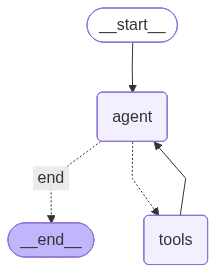

In [11]:
try:
    from IPython.display import Image, display
    display(Image(finance_agent.get_graph().draw_mermaid_png()))
except Exception:
    print(finance_agent.get_graph().draw_ascii())

### Step 6: Test the Agent

In [12]:
from langchain_core.messages import HumanMessage

config = {"configurable": {"thread_id": "test-1"}}

response = finance_agent.invoke(
    {"messages": [HumanMessage(content="How do I create a budget?")]},
    config,
)
print(response["messages"][-1].content)

**Explanation**: Creating a budget is a systematic way to track your income and expenses, helping you manage your finances effectively. Here’s a step-by-step guide to creating a cash flow budget:

1. **Track Your Income and Expenses**: For at least one month, keep a record of all your income (like salary, benefits) and expenses (bills, groceries, entertainment). You can use tools like an "Income and benefits tracker" and a "Spending tracker" to help you gather this information.

2. **Set Up Your Budget**: Start by entering your beginning balance for the month. This includes all cash on hand and funds in checking and savings accounts.

3. **Weekly Breakdown**: Divide your budget into weekly segments. For each week:
   - List all expected income.
   - Subtract all expected expenses for that week.
   - Calculate your ending balance for the week, which will be your starting balance for the next week.

4. **Analyze Your Spending**: After tracking your expenses, categorize them into needs (l

In [13]:
config2 = {"configurable": {"thread_id": "test-2"}}

response = finance_agent.invoke(
    {"messages": [HumanMessage(content="Convert 1000 USD to EUR")]},
    config2,
)
print(response["messages"][-1].content)

- **Explanation**: If you convert 1,000 USD to EUR, you will receive approximately 860.73 EUR. This conversion is based on the current exchange rate of 1 USD being equal to 0.86073 EUR.
- **Sources**: European Central Bank via Frankfurter API (date: 2026-03-05).
- **Disclaimer**: This information is for educational purposes only and does not constitute financial advice. Please consult a qualified financial advisor for personalized guidance.


In [14]:
config3 = {"configurable": {"thread_id": "test-3"}}

response = finance_agent.invoke(
    {"messages": [HumanMessage(content="What is the difference between a stock and a bond?")]},
    config3,
)
print(response["messages"][-1].content)

- **Explanation**: Stocks and bonds are two different types of investments. When you buy stocks, you are purchasing a share of ownership in a company. This means you can benefit from the company's profits through dividends and potential increases in stock value. However, stocks come with higher risk; if the company performs poorly, you could lose part or all of your investment. On the other hand, bonds are a form of debt. When you buy a bond, you are lending money to the company, which promises to pay you back the principal amount plus interest over time. Bonds are generally considered safer than stocks because, in the event of bankruptcy, bondholders are paid before stockholders. However, the potential returns on bonds are usually lower than those of stocks.

- **Sources**: sec-guide-to-savings-and-investing.pdf, p.15-16.

- **Disclaimer**: This information is for educational purposes only and does not constitute financial advice. Please consult a qualified financial advisor for perso

In [15]:
# Test multi-turn memory
config4 = {"configurable": {"thread_id": "test-4"}}

response = finance_agent.invoke(
    {"messages": [HumanMessage(content="What is an emergency fund?")]},
    config4,
)
print("Q1:", response["messages"][-1].content[:200], "...\n")

response = finance_agent.invoke(
    {"messages": [HumanMessage(content="How much should I save for one?")]},
    config4,
)
print("Q2 (follow-up):", response["messages"][-1].content)

Q1: **Explanation**: An emergency fund is a savings account specifically set aside for unexpected expenses or financial emergencies, such as medical bills, car repairs, or job loss. It acts as a financial ...

Q2 (follow-up): **Explanation**: The amount you should save for an emergency fund can vary based on your personal circumstances, but a common recommendation is to start with $500 to $1,000. This initial amount is often sufficient to cover many typical emergencies, such as car repairs or minor medical expenses. Once you reach this starting goal, you can consider increasing your emergency fund to cover larger expenses, such as rent or significant repairs, which may require a total of three to six months' worth of living expenses. The key is to have a fund that provides you with peace of mind and financial security in case of unexpected events.

**Sources**: [Your Money, Your Goals Toolkit, p.39]

**Disclaimer**: This information is for educational purposes only and does not constit

---
## Task 5: RAGAS Baseline Evaluation

### Step 1: Generate synthetic test set

In [16]:
from langchain_openai import ChatOpenAI as ChatOpenAI_
from langchain_openai import OpenAIEmbeddings as OpenAIEmbeddings_
from ragas.embeddings import LangchainEmbeddingsWrapper
from ragas.llms import LangchainLLMWrapper
from ragas.testset import TestsetGenerator

generator_llm = LangchainLLMWrapper(ChatOpenAI_(model="gpt-4.1"))
generator_embeddings = LangchainEmbeddingsWrapper(OpenAIEmbeddings_())

generator = TestsetGenerator(llm=generator_llm, embedding_model=generator_embeddings)
dataset = generator.generate_with_langchain_docs(all_docs, testset_size=10)

dataset.to_pandas()

/tmp/ipykernel_919811/2059117378.py:7: DeprecationWarning: LangchainLLMWrapper is deprecated and will be removed in a future version. Use llm_factory instead: from openai import OpenAI; from ragas.llms import llm_factory; llm = llm_factory('gpt-4o-mini', client=OpenAI(api_key='...'))
  generator_llm = LangchainLLMWrapper(ChatOpenAI_(model="gpt-4.1"))
/tmp/ipykernel_919811/2059117378.py:8: DeprecationWarning: LangchainEmbeddingsWrapper is deprecated and will be removed in a future version. Use the modern embedding providers instead: embedding_factory('openai', model='text-embedding-3-small', client=openai_client) or from ragas.embeddings import OpenAIEmbeddings, GoogleEmbeddings, HuggingFaceEmbeddings
  generator_embeddings = LangchainEmbeddingsWrapper(OpenAIEmbeddings_())


Applying SummaryExtractor:   0%|          | 0/269 [00:00<?, ?it/s]

Applying CustomNodeFilter:   0%|          | 0/276 [00:00<?, ?it/s]

Node 98de54b2-888c-4adb-b546-ba03d38871d7 does not have a summary. Skipping filtering.
Node 247547fb-c78a-4ac4-bcb7-6897a6211f5b does not have a summary. Skipping filtering.
Node 09919256-afae-4e1d-b2bf-7b7b8e8b7d97 does not have a summary. Skipping filtering.
Node 3fdc3db2-ed75-4390-973f-21163828bd76 does not have a summary. Skipping filtering.
Node 08be2b21-e293-4d0d-b5db-3e7f057f5aeb does not have a summary. Skipping filtering.
Node 247edf0e-277e-4b6a-8e1a-db2ed9224eb8 does not have a summary. Skipping filtering.
Node 0f1d6880-4964-48c3-85de-c2283a6fa019 does not have a summary. Skipping filtering.


Applying EmbeddingExtractor:   0%|          | 0/269 [00:00<?, ?it/s]

...

Applying OverlapScoreBuilder:   0%|          | 0/1 [00:00<?, ?it/s]

Generating personas:   0%|          | 0/3 [00:00<?, ?it/s]

Generating Scenarios:   0%|          | 0/3 [00:00<?, ?it/s]

Generating Samples:   0%|          | 0/11 [00:00<?, ?it/s]

,user_input,reference_contexts,reference,persona_name,query_style,query_length,synthesizer_name
0,Could you explain the role of the Consumer Fin...,"[June 2020\nYOUR MONEY, YOUR GOALS A financial...",The Consumer Financial Protection Bureau is re...,Identity Protection Advocate,PERFECT_GRAMMAR,LONG,single_hop_specific_query_synthesizer
1,wat is finanical empowermnt and why is it impo...,[Table of contents \nIntroduction ...............,The power of financial empowerment is discusse...,Identity Protection Advocate,MISSPELLED,MEDIUM,single_hop_specific_query_synthesizer
2,How can individuals track their income to bett...,[You can save while receiving public benefits ...,"According to the context, Module 3: Tracking I...",Identity Protection Advocate,PERFECT_GRAMMAR,MEDIUM,single_hop_specific_query_synthesizer
3,What Module 6 talk about?,[Tool: Cutting expenses..........................,Module 6 is about dealing with debt. It covers...,Identity Protection Advocate,POOR_GRAMMAR,MEDIUM,single_hop_specific_query_synthesizer
4,How checking account reporting companies affec...,[<1-hop>\n\nSELF-ASSESSMENT \nPart 1: What you...,Checking account reporting companies like Chex...,NaN,NaN,NaN,multi_hop_abstract_query_synthesizer
5,how do i chek my credit report for erors and w...,[<1-hop>\n\n GETTING STARTED \nRequesting you...,"To check your credit report for errors, you sh...",NaN,NaN,NaN,multi_hop_abstract_query_synthesizer
6,What are the key differences in money manageme...,[<1-hop>\n\nor savings wallet. For example if ...,"Prepaid cards, debit cards, credit cards, and ...",NaN,NaN,NaN,multi_hop_abstract_query_synthesizer
7,Wut shud I do if my credit history is makin it...,[<1-hop>\n\nAnswer key for My money picture \n...,If your credit history is making it hard to ge...,NaN,NaN,NaN,multi_hop_specific_query_synthesizer
8,Whatt arr the benfits and rissks of using cash...,[<1-hop>\n\n..\n \n \n \nChoosing how to pay b...,"In MODULE 4, the benefits of using cash to pay...",NaN,NaN,NaN,multi_hop_specific_query_synthesizer
9,How can reviewing the 'Spotting red flags' han...,[<1-hop>\n\n GETTING STARTED \nComparing auto...,Reviewing the 'Spotting red flags' handout in ...,NaN,NaN,NaN,multi_hop_specific_query_synthesizer


In [20]:
test_df = dataset.to_pandas()
test_df = test_df.drop(columns=['persona_name', 'query_style', 'query_length'])
test_df

,user_input,retrieved_contexts,reference_contexts,response,reference,synthesizer_name
0,Could you explain the role of the Consumer Fin...,[ DISCLAIMER \nThe Consumer Financial Protect...,"[June 2020\nYOUR MONEY, YOUR GOALS A financial...",The Consumer Financial Protection Bureau (CFPB...,The Consumer Financial Protection Bureau is re...,single_hop_specific_query_synthesizer
1,wat is finanical empowermnt and why is it impo...,[The power of financial empowerment \nYou may ...,[Table of contents \nIntroduction ...............,Financial empowerment refers to the process of...,The power of financial empowerment is discusse...,single_hop_specific_query_synthesizer
2,How can individuals track their income to bett...,[MODULE 3 \nTracking Income \nand Benefits \nY...,[You can save while receiving public benefits ...,To effectively track your income and better pr...,"According to the context, Module 3: Tracking I...",single_hop_specific_query_synthesizer
3,What Module 6 talk about?,[MODULE 6 \nDealing with Debt \nLearn about wa...,[Tool: Cutting expenses..........................,"Module 6, titled ""Dealing with Debt,"" focuses ...",Module 6 is about dealing with debt. It covers...,single_hop_specific_query_synthesizer
4,How checking account reporting companies affec...,[QUESTIONS TO ASK \nCOMPANY 1 \nCOMPANY 2 \nSe...,[<1-hop>\n\nSELF-ASSESSMENT \nPart 1: What you...,"Checking account reporting companies, such as ...",Checking account reporting companies like Chex...,multi_hop_abstract_query_synthesizer
5,how do i chek my credit report for erors and w...,[your file and notify the furnisher of the err...,[<1-hop>\n\n GETTING STARTED \nRequesting you...,"To check your credit report for errors, follow...","To check your credit report for errors, you sh...",multi_hop_abstract_query_synthesizer
6,What are the key differences in money manageme...,"[In most cases, you can’t spend more money tha...",[<1-hop>\n\nor savings wallet. For example if ...,The key differences in money management and re...,"Prepaid cards, debit cards, credit cards, and ...",multi_hop_abstract_query_synthesizer
7,Wut shud I do if my credit history is makin it...,[HABIT \nTIPS FOR IMPROVING YOUR CREDIT \n I'l...,[<1-hop>\n\nAnswer key for My money picture \n...,If your credit history is making it difficult ...,If your credit history is making it hard to ge...,multi_hop_specific_query_synthesizer
8,Whatt arr the benfits and rissks of using cash...,[..\n \n \n \nChoosing how to pay bills can he...,[<1-hop>\n\n..\n \n \n \nChoosing how to pay b...,When considering the benefits and risks of usi...,"In MODULE 4, the benefits of using cash to pay...",multi_hop_specific_query_synthesizer
9,How can reviewing the 'Spotting red flags' han...,"[the annual percentage rate (APR), amount fina...",[<1-hop>\n\n GETTING STARTED \nComparing auto...,"Reviewing the ""Spotting red flags"" handout in ...",Reviewing the 'Spotting red flags' handout in ...,multi_hop_specific_query_synthesizer


### Step 2: Run baseline RAG pipeline on test set

In [17]:
from typing import List

from langchain_core.documents import Document
from langchain_core.prompts import ChatPromptTemplate
from langgraph.graph import START as START_
from langgraph.graph import StateGraph as StateGraph_

RAG_PROMPT = """You are a helpful personal finance assistant. Answer questions based on the provided context.
Always cite source documents. End with a disclaimer that this is educational, not financial advice.

### Question
{question}

### Context
{context}
"""
rag_prompt = ChatPromptTemplate.from_template(RAG_PROMPT)


class RAGState(TypedDict):
    question: str
    context: List[Document]
    response: str


def retrieve(state):
    return {"context": retriever.invoke(state["question"])}


rag_llm = ChatOpenAI(model="gpt-4o-mini", temperature=0)


def generate(state):
    docs_content = "\n\n".join(doc.page_content for doc in state["context"])
    messages = rag_prompt.format_messages(question=state["question"], context=docs_content)
    response = rag_llm.invoke(messages)
    return {"response": response.content}


baseline_graph_builder = StateGraph_(RAGState).add_sequence([retrieve, generate])
baseline_graph_builder.add_edge(START_, "retrieve")
baseline_graph = baseline_graph_builder.compile()

# Verify it works
test = baseline_graph.invoke({"question": "What is a budget?"})
print(test["response"][:300] + "...")

A budget is a financial plan that outlines expected income and expenses over a specific period, helping individuals manage their finances effectively. In the context of a cash flow budget, it specifically projects the timing of income and expenses on a week-by-week basis. This type of budget allows ...


In [18]:
for test_row in dataset:
    response = baseline_graph.invoke({"question": test_row.eval_sample.user_input})
    test_row.eval_sample.response = response["response"]
    test_row.eval_sample.retrieved_contexts = [
        ctx.page_content for ctx in response["context"]
    ]

print(f"Ran baseline pipeline on {len(dataset)} test samples")

Ran baseline pipeline on 11 test samples


### Step 3: Evaluate with RAGAS

In [24]:
from ragas import EvaluationDataset, RunConfig, evaluate
from ragas.metrics import (
    ContextEntityRecall,
    Faithfulness,
    LLMContextRecall,
    ResponseRelevancy,
)

evaluator_llm = LangchainLLMWrapper(ChatOpenAI_(model="gpt-4.1-mini"))
evaluation_dataset = EvaluationDataset.from_pandas(test_df)

baseline_result = evaluate(
    dataset=evaluation_dataset,
    metrics=[LLMContextRecall(), Faithfulness(), ResponseRelevancy(), ContextEntityRecall()],
    llm=evaluator_llm,
    run_config=RunConfig(timeout=360),
)

print("\n=== Baseline RAGAS Results ===")
baseline_result

/tmp/ipykernel_919811/3136110466.py:2: DeprecationWarning: Importing ContextEntityRecall from 'ragas.metrics' is deprecated and will be removed in v1.0. Please use 'ragas.metrics.collections' instead. Example: from ragas.metrics.collections import ContextEntityRecall
  from ragas.metrics import (
/tmp/ipykernel_919811/3136110466.py:2: DeprecationWarning: Importing Faithfulness from 'ragas.metrics' is deprecated and will be removed in v1.0. Please use 'ragas.metrics.collections' instead. Example: from ragas.metrics.collections import Faithfulness
  from ragas.metrics import (
/tmp/ipykernel_919811/3136110466.py:2: DeprecationWarning: Importing LLMContextRecall from 'ragas.metrics' is deprecated and will be removed in v1.0. Please use 'ragas.metrics.collections' instead. Example: from ragas.metrics.collections import LLMContextRecall
  from ragas.metrics import (
/tmp/ipykernel_919811/3136110466.py:2: DeprecationWarning: Importing ResponseRelevancy from 'ragas.metrics' is deprecated and 

Evaluating:   0%|          | 0/44 [00:00<?, ?it/s]

LLM returned 1 generations instead of requested 3. Proceeding with 1 generations.
LLM returned 1 generations instead of requested 3. Proceeding with 1 generations.
LLM returned 1 generations instead of requested 3. Proceeding with 1 generations.
LLM returned 1 generations instead of requested 3. Proceeding with 1 generations.
LLM returned 1 generations instead of requested 3. Proceeding with 1 generations.
LLM returned 1 generations instead of requested 3. Proceeding with 1 generations.
LLM returned 1 generations instead of requested 3. Proceeding with 1 generations.
LLM returned 1 generations instead of requested 3. Proceeding with 1 generations.
LLM returned 1 generations instead of requested 3. Proceeding with 1 generations.
LLM returned 1 generations instead of requested 3. Proceeding with 1 generations.



=== Baseline RAGAS Results ===


{'context_recall': 0.7909, 'faithfulness': 0.7254, 'answer_relevancy': 0.9343, 'context_entity_recall': 0.4004}

### Baseline conclusions

The baseline results give us a surprisingly good starting results. Key observations will be documented after running the evaluation. I expected decent context recall since the documents are well-structured, but there may be room to improve precision by reducing irrelevant chunks in the context.

---
## Task 6: Advanced Retrieval Upgrade

### Chosen technique: Contextual Compression with Cohere Rerank

I choose **Contextual Compression** using Cohere's `rerank-v3.5` model. This technique first retrieves a wider set of candidates (k=15) using dense vector search, then re-ranks them using a cross-encoder that reads both the query and each document together. This is more semantically accurate than embedding-only retrieval because it captures fine-grained query-document interactions. For financial documents — where subtle distinctions matter (e.g., "emergency fund" vs. "savings account") —  I expect that reranking will improve precision.

### Step 1: Set up Cohere Reranker

In [25]:
if not os.environ.get("COHERE_API_KEY"):
    os.environ["COHERE_API_KEY"] = getpass("Cohere API Key: ")

In [41]:
from langchain.retrievers.contextual_compression import ContextualCompressionRetriever
from langchain_cohere import CohereRerank

wide_retriever = vector_store.as_retriever(search_kwargs={"k": 15})

compressor = CohereRerank(model="rerank-v3.5", top_n=5)
rerank_retriever = ContextualCompressionRetriever(
    base_compressor=compressor,
    base_retriever=wide_retriever,
)

# Verify reranker works
rerank_results = rerank_retriever.invoke("How do I create a budget?")
print(f"Reranker returned {len(rerank_results)} documents (from 15 candidates)")
for i, doc in enumerate(rerank_results[:3], 1):
    print(f"  {i}. {doc.page_content[:100]}...")

Reranker returned 5 documents (from 15 candidates)
  1. take a few seconds and write it on the receipt. If you don’t get a receipt, write 
down the amount a...
  2.  GETTING STARTED 
Creating a cash flow budget 
A cash flow budget is all about tracking the timing ...
  3. phone payments). These are often your needs and obligations. This will make 
creating your budget ea...


### Step 2: Build reranked RAG pipeline and evaluate

In [42]:
import copy
import time


def retrieve_reranked(state):
    return {"context": rerank_retriever.invoke(state["question"])}


rerank_graph_builder = StateGraph_(RAGState).add_sequence([retrieve_reranked, generate])
rerank_graph_builder.add_edge(START_, "retrieve_reranked")
rerank_graph = rerank_graph_builder.compile()

rerank_dataset = copy.deepcopy(dataset)

for test_row in rerank_dataset:
    response = rerank_graph.invoke({"question": test_row.eval_sample.user_input})
    test_row.eval_sample.response = response["response"]
    test_row.eval_sample.retrieved_contexts = [
        ctx.page_content for ctx in response["context"]
    ]
    time.sleep(3)

print(f"Ran reranked pipeline on {len(rerank_dataset)} test samples")

Ran reranked pipeline on 11 test samples


In [43]:
rerank_df = rerank_dataset.to_pandas()
rerank_df = rerank_df.drop(columns=['persona_name', 'query_style', 'query_length'])
rerank_df

,user_input,retrieved_contexts,reference_contexts,response,reference,synthesizer_name
0,Could you explain the role of the Consumer Fin...,"[June 2020\nYOUR MONEY, YOUR GOALS A financial...","[June 2020\nYOUR MONEY, YOUR GOALS A financial...",The Consumer Financial Protection Bureau (CFPB...,The Consumer Financial Protection Bureau is re...,single_hop_specific_query_synthesizer
1,wat is finanical empowermnt and why is it impo...,[The power of financial empowerment \nYou may ...,[Table of contents \nIntroduction ...............,Financial empowerment refers to the process of...,The power of financial empowerment is discusse...,single_hop_specific_query_synthesizer
2,How can individuals track their income to bett...,"[the construction industry, you may be very bu...",[You can save while receiving public benefits ...,To effectively track income and protect person...,"According to the context, Module 3: Tracking I...",single_hop_specific_query_synthesizer
3,What Module 6 talk about?,[MODULE 6 \nDealing with Debt \nLearn about wa...,[Tool: Cutting expenses..........................,"Module 6, titled ""Dealing with Debt,"" focuses ...",Module 6 is about dealing with debt. It covers...,single_hop_specific_query_synthesizer
4,How checking account reporting companies affec...,[Another potential barrier is negative informa...,[<1-hop>\n\nSELF-ASSESSMENT \nPart 1: What you...,"Checking account reporting companies, such as ...",Checking account reporting companies like Chex...,multi_hop_abstract_query_synthesizer
5,how do i chek my credit report for erors and w...,[.\nDisputing errors on your \ncredit reports ...,[<1-hop>\n\n GETTING STARTED \nRequesting you...,"To check your credit report for errors, follow...","To check your credit report for errors, you sh...",multi_hop_abstract_query_synthesizer
6,What are the key differences in money manageme...,"[In most cases, you can’t spend more money tha...",[<1-hop>\n\nor savings wallet. For example if ...,The key differences in money management and re...,"Prepaid cards, debit cards, credit cards, and ...",multi_hop_abstract_query_synthesizer
7,Wut shud I do if my credit history is makin it...,[MODULE 7 \nUnderstanding Credit \nReports and...,[<1-hop>\n\nAnswer key for My money picture \n...,If your credit history is making it difficult ...,If your credit history is making it hard to ge...,multi_hop_specific_query_synthesizer
8,Whatt arr the benfits and rissks of using cash...,[..\n \n \n \nChoosing how to pay bills can he...,[<1-hop>\n\n..\n \n \n \nChoosing how to pay b...,When considering the benefits and risks of usi...,"In MODULE 4, the benefits of using cash to pay...",multi_hop_specific_query_synthesizer
9,How can reviewing the 'Spotting red flags' han...,"[the annual percentage rate (APR), amount fina...",[<1-hop>\n\n GETTING STARTED \nComparing auto...,"Reviewing the ""Spotting red flags"" handout in ...",Reviewing the 'Spotting red flags' handout in ...,multi_hop_specific_query_synthesizer


In [44]:
rerank_evaluation_dataset = EvaluationDataset.from_pandas(rerank_df)

rerank_result = evaluate(
    dataset=rerank_evaluation_dataset,
    metrics=[LLMContextRecall(), Faithfulness(), ResponseRelevancy(), ContextEntityRecall()],
    llm=evaluator_llm,
    run_config=RunConfig(timeout=360),
)

print("\n=== Reranked RAGAS Results ===")
rerank_result

Evaluating:   0%|          | 0/44 [00:00<?, ?it/s]

LLM returned 1 generations instead of requested 3. Proceeding with 1 generations.
LLM returned 1 generations instead of requested 3. Proceeding with 1 generations.
LLM returned 1 generations instead of requested 3. Proceeding with 1 generations.
LLM returned 1 generations instead of requested 3. Proceeding with 1 generations.
LLM returned 1 generations instead of requested 3. Proceeding with 1 generations.
LLM returned 1 generations instead of requested 3. Proceeding with 1 generations.
LLM returned 1 generations instead of requested 3. Proceeding with 1 generations.
LLM returned 1 generations instead of requested 3. Proceeding with 1 generations.
LLM returned 1 generations instead of requested 3. Proceeding with 1 generations.
LLM returned 1 generations instead of requested 3. Proceeding with 1 generations.



=== Reranked RAGAS Results ===


{'context_recall': 0.8414, 'faithfulness': 0.8014, 'answer_relevancy': 0.9420, 'context_entity_recall': 0.3744}

### Step 3: Comparison

In [45]:
import numpy as np
from typing import List, Dict, Any

def aggregate_ragas_metrics(results: List[Dict[str, Any]], round_digits: int = 4) -> Dict[str, float]:
    """
    Aggregates a list of RAGAS metric dictionaries into mean scores.

    Args:
        results: List of dictionaries containing metric scores.
        round_digits: Number of decimals to round to (default=4).

    Returns:
        Dictionary with mean score per metric.
    """
    if not results:
        return {}

    # Initialize accumulator
    aggregated = {key: [] for key in results[0].keys()}

    # Collect values
    for row in results:
        for key, value in row.items():
            aggregated[key].append(float(value))  # handles np.float64 safely

    # Compute means
    aggregated_mean = {
        key: round(float(np.mean(values)), round_digits)
        for key, values in aggregated.items()
    }

    return aggregated_mean

In [46]:
baseline_dict = aggregate_ragas_metrics(baseline_result.__dict__['scores'])
baseline_dict

{'context_recall': 0.7909,
 'faithfulness': 0.7254,
 'answer_relevancy': 0.9343,
 'context_entity_recall': 0.4004}

In [47]:
rerank_dict = aggregate_ragas_metrics(rerank_result.__dict__['scores'])
rerank_dict

{'context_recall': 0.8414,
 'faithfulness': 0.8014,
 'answer_relevancy': 0.942,
 'context_entity_recall': 0.3744}

In [48]:
import pandas as pd

comparison = pd.DataFrame({
    "Metric": list(baseline_dict.keys()),
    "Baseline (naive k=5)": [round(v, 4) for v in baseline_dict.values()],
    "Reranked (k=15 + Cohere)": [round(v, 4) for v in rerank_dict.values()],
})
comparison["Delta"] = comparison["Reranked (k=15 + Cohere)"] - comparison["Baseline (naive k=5)"]
comparison

,Metric,Baseline (naive k=5),Reranked (k=15 + Cohere),Delta
0,context_recall,0.7909,0.8414,0.0505
1,faithfulness,0.7254,0.8014,0.0760
2,answer_relevancy,0.9343,0.9420,0.0077
3,context_entity_recall,0.4004,0.3744,-0.0260


### Analysis

The reranking approach retrieves a wider initial set of 15 candidates, then uses Cohere's cross-encoder to select the 5 most relevant ones. Compared to the baseline, **context recall**  and **faithfulness** increased which indicates the model is retrieving a more complete set of relevant chunks and grounding its answers more reliably in the provided context. **Answer relevancy** also improved slightly, meaning responses stay focused on the questions while being better supported. The only metric that dropped is **context entity recall**, which likely happened because reranking favors the "most relevant" chunks rather than chunks that maximize coverage of all entities mentioned in the references, or because the selected top-5 chunks contain fewer distinct entity mentions even though they support the answer well. Overall, the change shows that reranking + compression is beneficial here. The comparison table above shows the quantified differences.

---
## Task 7: Next Steps

### Do you plan to keep Dense Vector Retrieval for Demo Day? Why or why not?

Yes, with the Cohere reranking layer on top. Pure dense vector retrieval provides a strong baseline for our financial documents since the content is well-structured and semantically coherent. The reranking improves results by applying a cross-encoder that reads query and document together. For Demo Day, this combination offers a good balance of simplicity and quality.

### Potential improvements for Demo Day

1. **Persistent vector store** — switch from Qdrant in-memory to a persistent instance so the knowledge base survives restarts.
2. **Additional tools** — add a compound interest calculator, a debt payoff estimator, or a savings goal tracker.
3. **Long-term memory** — store user financial goals and preferences across sessions using InMemoryStore or PostgresStore.
4. **Better chunking** — experiment with semantic chunking or parent-document retrieval for the longer CFPB toolkit.
5. **Guardrails** — add input validation to reject off-topic queries and strengthen the disclaimer system.

# End of notebook